Final sample: 2,002,707 rows
Censored: 325,181 (16.2%)
Employers: 3587  |  Levels: 4

Fitting hierarchical EM Tobit...
  Iter   0: ll=-15389.7501  beta0=0.1497  sigma=0.0845  sigma_E=0.1095  sigma_L=0.0043
  Iter   1: ll=626314.1426  beta0=0.1468  sigma=0.1260  sigma_E=0.1096  sigma_L=0.0046
  Iter   2: ll=642693.1127  beta0=0.1349  sigma=0.1271  sigma_E=0.1135  sigma_L=0.0045
  Iter   3: ll=652817.6996  beta0=0.1337  sigma=0.1293  sigma_E=0.1161  sigma_L=0.0045
  Iter   4: ll=656460.4473  beta0=0.1327  sigma=0.1301  sigma_E=0.1176  sigma_L=0.0045
  Iter  20: ll=660915.7683  beta0=0.1312  sigma=0.1313  sigma_E=0.1210  sigma_L=0.0045
  Converged at iteration 37.

Fitting pooled baseline...
  EM TOBIT MODEL — PARAMETER ESTIMATES
  Intercept (beta0):       0.1311
  sigma  (residual):       0.1313
  sigma_E (employer):      0.1212
  sigma_L (level):         0.0045
  Converged in:          38 iterations
  Final log-likelihood:   660960.93

  Level Effects (gamma_k):
    Level I: +0.0074
   

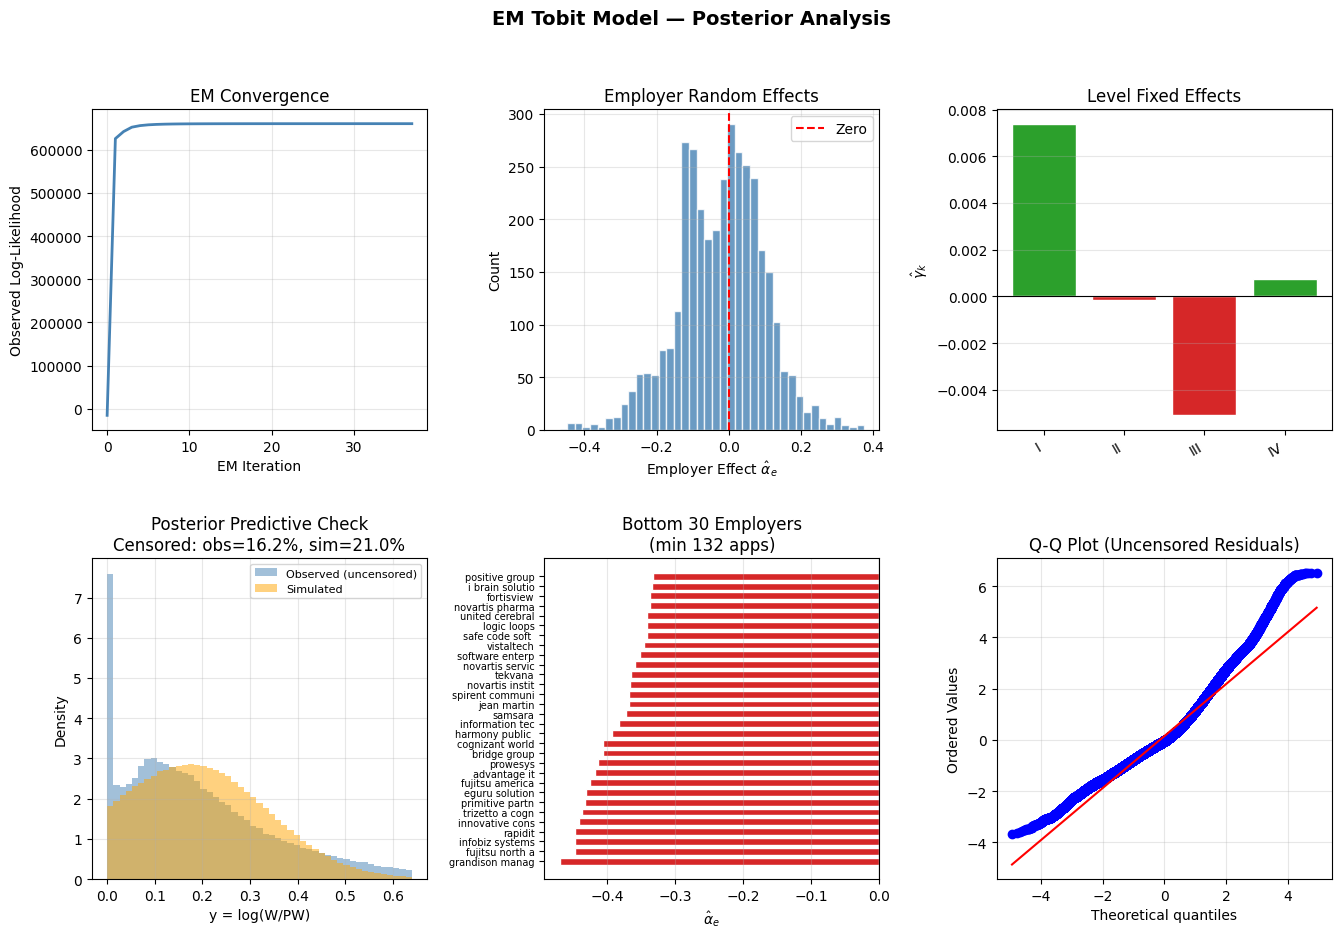

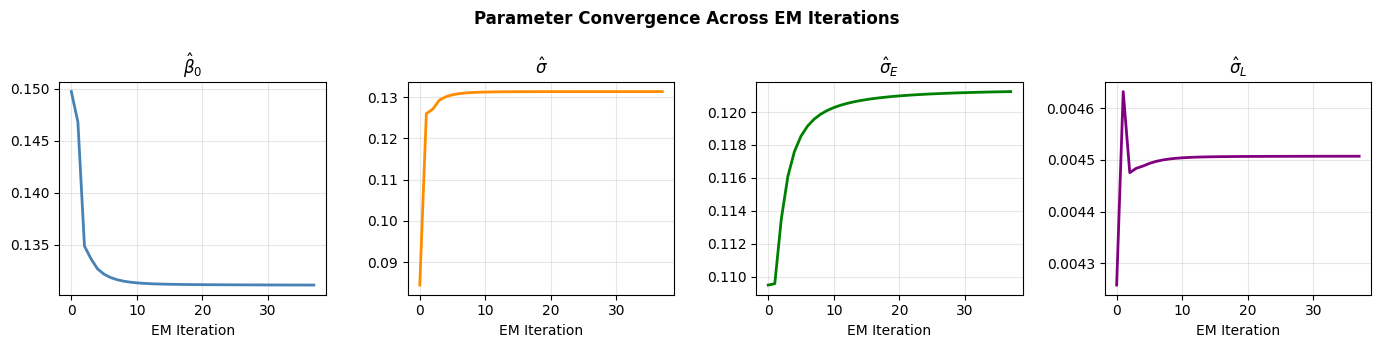


Employer effects saved to employer_effects.csv


In [1]:
"""
EM Algorithm for Hierarchical Tobit Model

Model:
    y_i = max(y_i*, 0)
    y_i* ~ N(mu_i, sigma^2)
    mu_i = beta0 + gamma_{L_i} + alpha_{emp(i)}
    alpha_e ~ N(0, sigma_E^2)
    gamma_k ~ N(0, sigma_L^2)

EM treats (y_i* for censored obs) as missing data.
Random effects are estimated as penalized (MAP) fixed quantities in the M-step.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.sparse import csc_matrix
from scipy.sparse.linalg import spsolve
import warnings
warnings.filterwarnings('ignore')

def prepare_data(df, wage_col='W', prevailing_wage_col='PW',
                 level_col='wage_level', employer_col='employer_id'):
    df = df.copy().dropna(subset=[wage_col, prevailing_wage_col, level_col, employer_col])
    y_raw = np.log(df[wage_col] / df[prevailing_wage_col])
    y = np.maximum(y_raw, 0.0)
    censored = (y == 0)
    levels = pd.Categorical(df[level_col])
    employers = pd.Categorical(df[employer_col])
    L = levels.codes
    E = employers.codes
    K = levels.categories.nunique() if hasattr(levels.categories, 'nunique') else len(levels.categories)
    N_E = len(employers.categories)

    return {
        'y': y.values,
        'censored': censored.values,
        'L': L,
        'E': E,
        'K': K,
        'N_E': N_E,
        'n': len(y),
        'level_labels': list(levels.categories),
        'employer_labels': list(employers.categories),
    }

def truncated_normal_moments(mu, sigma, upper=0.0):
    """
    E[X | X <= upper] and E[X^2 | X <= upper] for X ~ N(mu, sigma^2).
    Used in E-step for censored observations.
    """
    alpha = (upper - mu) / sigma
    phi_a = stats.norm.pdf(alpha)
    Phi_a = stats.norm.cdf(alpha)
    safe_Phi = np.where(Phi_a < 1e-300, 1e-300, Phi_a)
    ratio = phi_a / safe_Phi

    E1 = mu - sigma * ratio
    E2 = mu**2 + sigma**2 - sigma * (mu + sigma * ratio) * ratio

    return E1, E2

def e_step(y, censored, mu, sigma):
    """
    Compute E[y_i* | obs] and E[y_i*^2 | obs] for all i.
    """
    y_star = y.copy().astype(float)
    y_star2 = (y**2).copy().astype(float)

    if censored.any():
        E1, E2 = truncated_normal_moments(mu[censored], sigma, upper=0.0)
        y_star[censored] = E1
        y_star2[censored] = E2

    return y_star, y_star2

def m_step(y_star, y_star2, L, E, K, N_E, sigma2, sigma_E2, sigma_L2):
    """
    Solve penalized least squares for beta0, gamma (K), alpha (N_E).

    Design: y* = X beta0 + Z_L gamma + Z_E alpha + eps
    Penalization: lambda_L = sigma2/sigma_L2, lambda_E = sigma2/sigma_E2
    """
    n = len(y_star)
    lam_L = sigma2 / sigma_L2
    lam_E = sigma2 / sigma_E2

    n_L = np.bincount(L, minlength=K)           # count per level
    n_E = np.bincount(E, minlength=N_E)         # count per employer

    Sy_L = np.bincount(L, weights=y_star, minlength=K)
    Sy_E = np.bincount(E, weights=y_star, minlength=N_E)
    Sy_total = y_star.sum()

    # Iterative backfitting (coordinate descent on the normal equations)
    beta0 = 0.0
    gamma = np.zeros(K)
    alpha = np.zeros(N_E)

    for _ in range(200):
        beta0_new = (Sy_total - (gamma[L] + alpha[E]).sum()) / n

        # Update gamma_k
        resid_L = Sy_L - n_L * beta0_new - np.bincount(L, weights=alpha[E], minlength=K)
        gamma_new = resid_L / (n_L + lam_L)

        # Update alpha_e
        resid_E = Sy_E - n_E * beta0_new - np.bincount(E, weights=gamma_new[L], minlength=N_E)
        alpha_new = resid_E / (n_E + lam_E)

        # Check convergence
        delta = (np.abs(beta0_new - beta0) +
                 np.abs(gamma_new - gamma).max() +
                 np.abs(alpha_new - alpha).max())
        beta0, gamma, alpha = beta0_new, gamma_new, alpha_new
        if delta < 1e-8:
            break

    mu_hat = beta0 + gamma[L] + alpha[E]

    # Update variance components
    resid2 = y_star2 - 2 * y_star * mu_hat + mu_hat**2
    sigma2_new = resid2.mean()
    sigma2_new = max(sigma2_new, 1e-6)

    sigma_E2_new = (alpha**2).mean()
    sigma_E2_new = max(sigma_E2_new, 1e-6)

    sigma_L2_new = (gamma**2).mean()
    sigma_L2_new = max(sigma_L2_new, 1e-6)

    return beta0, gamma, alpha, sigma2_new, sigma_E2_new, sigma_L2_new, mu_hat

def observed_log_likelihood(y, censored, mu, sigma):
    """
    log p(y | theta) = sum_uncensored log phi((y-mu)/sigma) / sigma
                     + sum_censored  log Phi(-mu/sigma)
    """
    ll = 0.0
    if (~censored).any():
        ll += stats.norm.logpdf(y[~censored], loc=mu[~censored], scale=sigma).sum()
    if censored.any():
        ll += stats.norm.logcdf(0, loc=mu[censored], scale=sigma).sum()
    return ll

def fit_em(data, max_iter=100, tol=1, verbose=True):
    """
    Run EM algorithm. Returns dict of parameter estimates and diagnostics.
    """
    y, censored = data['y'], data['censored']
    L, E = data['L'], data['E']
    K, N_E, n = data['K'], data['N_E'], data['n']

    # Initialize parameters
    beta0 = np.mean(y[~censored]) if (~censored).any() else 0.0
    gamma = np.zeros(K)
    alpha = np.zeros(N_E)
    sigma2 = np.var(y[~censored]) if (~censored).any() else 1.0
    sigma_E2 = 0.1
    sigma_L2 = 0.1

    lls = []
    params_history = []

    for it in range(max_iter):
        mu = beta0 + gamma[L] + alpha[E]
        sigma = np.sqrt(sigma2)
        y_star, y_star2 = e_step(y, censored, mu, sigma)
        beta0, gamma, alpha, sigma2, sigma_E2, sigma_L2, mu_new = m_step(
            y_star, y_star2, L, E, K, N_E, sigma2, sigma_E2, sigma_L2
        )
        ll = observed_log_likelihood(y, censored, mu_new, np.sqrt(sigma2))
        lls.append(ll)

        params_history.append({
            'beta0': beta0, 'sigma': np.sqrt(sigma2),
            'sigma_E': np.sqrt(sigma_E2), 'sigma_L': np.sqrt(sigma_L2)
        })

        if verbose and (it % 20 == 0 or it < 5):
            print(f"  Iter {it:3d}: ll={ll:.4f}  beta0={beta0:.4f}  "
                  f"sigma={np.sqrt(sigma2):.4f}  sigma_E={np.sqrt(sigma_E2):.4f}  "
                  f"sigma_L={np.sqrt(sigma_L2):.4f}")
        if it > 0 and abs(lls[-1] - lls[-2]) < tol:
            if verbose:
                print(f"  Converged at iteration {it}.")
            break

    return {
        'beta0': beta0,
        'gamma': gamma,
        'alpha': alpha,
        'sigma': np.sqrt(sigma2),
        'sigma_E': np.sqrt(sigma_E2),
        'sigma_L': np.sqrt(sigma_L2),
        'log_likelihoods': np.array(lls),
        'params_history': params_history,
        'n_iter': len(lls),
        'data': data,
    }

def bootstrap_se(data, n_boot=200, seed=42, verbose=False):
    """
    Parametric bootstrap for SEs on top-level parameters.
    (Louis's method for full Fisher info is complex with random effects;
     bootstrap is more practical here.)
    """
    rng = np.random.default_rng(seed)
    n = data['n']
    records = []
    res = fit_em(data, verbose=False)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_data = {
            'y': data['y'][idx],
            'censored': data['censored'][idx],
            'L': data['L'][idx],
            'E': data['E'][idx],
            'K': data['K'],
            'N_E': data['N_E'],
            'n': n,
        }
        try:
            r = fit_em(boot_data, verbose=False, tol=1e-4)
            records.append({
                'beta0': r['beta0'],
                'sigma': r['sigma'],
                'sigma_E': r['sigma_E'],
                'sigma_L': r['sigma_L'],
            })
        except Exception:
            continue

    df_boot = pd.DataFrame(records)
    se = df_boot.std()
    return se, df_boot

def fit_pooled_tobit(data, max_iter=100, tol=1):
    """Simple Tobit with only a global intercept (no random effects)."""
    y, censored = data['y'], data['censored']
    n = len(y)
    beta0 = np.mean(y[~censored]) if (~censored).any() else 0.0
    sigma2 = np.var(y[~censored]) if (~censored).any() else 1.0

    lls = []
    for _ in range(max_iter):
        sigma = np.sqrt(sigma2)
        mu = np.full(n, beta0)

        y_star, y_star2 = e_step(y, censored, mu, sigma)

        beta0 = y_star.mean()
        sigma2 = max((y_star2 - 2 * y_star * beta0 + beta0**2).mean(), 1e-6)

        ll = observed_log_likelihood(y, censored, np.full(n, beta0), np.sqrt(sigma2))
        lls.append(ll)
        if len(lls) > 1 and abs(lls[-1] - lls[-2]) < tol:
            break

    return {'beta0': beta0, 'sigma': np.sqrt(sigma2), 'log_likelihood': lls[-1]}

def plot_results(result, top_n_employers=30, save_path=None):
    """Generate a 2x3 diagnostic figure."""
    data = result['data']
    lls = result['log_likelihoods']
    alpha = result['alpha']
    gamma = result['gamma']
    mu = result['beta0'] + gamma[data['L']] + alpha[data['E']]
    sigma = result['sigma']
    y = data['y']
    censored = data['censored']

    fig = plt.figure(figsize=(16, 10))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    # --- Panel 1: EM convergence ---
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(lls, color='steelblue', lw=2)
    ax1.set_xlabel('EM Iteration')
    ax1.set_ylabel('Observed Log-Likelihood')
    ax1.set_title('EM Convergence')
    ax1.grid(True, alpha=0.3)

    # --- Panel 2: Distribution of employer effects ---
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.hist(alpha, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax2.axvline(0, color='red', linestyle='--', lw=1.5, label='Zero')
    ax2.set_xlabel(r'Employer Effect $\hat{\alpha}_e$')
    ax2.set_ylabel('Count')
    ax2.set_title('Employer Random Effects')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # --- Panel 3: Level effects ---
    ax3 = fig.add_subplot(gs[0, 2])
    level_labels = data['level_labels']
    colors = ['#d62728' if g < 0 else '#2ca02c' for g in gamma]
    ax3.bar(range(len(gamma)), gamma, color=colors, edgecolor='white')
    ax3.axhline(0, color='black', lw=0.8)
    ax3.set_xticks(range(len(gamma)))
    ax3.set_xticklabels([str(l) for l in level_labels], rotation=30, ha='right')
    ax3.set_ylabel(r'$\hat{\gamma}_k$')
    ax3.set_title('Level Fixed Effects')
    ax3.grid(True, alpha=0.3, axis='y')

    # --- Panel 4: Posterior predictive check ---
    ax4 = fig.add_subplot(gs[1, 0])
    # Simulate from fitted model
    np.random.seed(0)
    y_sim_star = np.random.normal(mu, sigma)
    y_sim = np.maximum(y_sim_star, 0)
    bins = np.linspace(0, np.percentile(y[~censored], 99), 50)
    ax4.hist(y[y > 0], bins=bins, density=True, alpha=0.5, label='Observed (uncensored)', color='steelblue')
    ax4.hist(y_sim[y_sim > 0], bins=bins, density=True, alpha=0.5, label='Simulated', color='orange')
    frac_obs = censored.mean()
    frac_sim = (y_sim == 0).mean()
    ax4.set_xlabel('y = log(W/PW)')
    ax4.set_ylabel('Density')
    ax4.set_title(f'Posterior Predictive Check\n'
                  f'Censored: obs={frac_obs:.1%}, sim={frac_sim:.1%}')
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)

    # --- Panel 5: Top underpaying employers ---
    ax5 = fig.add_subplot(gs[1, 1])
    n_emp_to_show = min(top_n_employers, len(alpha))
    emp_counts = np.bincount(data['E'], minlength=data['N_E'])
    min_obs = max(5, int(np.percentile(emp_counts[emp_counts > 0], 25)))
    eligible = np.where(emp_counts >= min_obs)[0]

    if len(eligible) >= 10:
        sorted_idx = eligible[np.argsort(alpha[eligible])[:n_emp_to_show]]
        vals = alpha[sorted_idx]
        emp_labels = [str(data['employer_labels'][i])[:15] for i in sorted_idx]
        colors_emp = ['#d62728' if v < 0 else '#2ca02c' for v in vals]
        ax5.barh(range(len(vals)), vals, color=colors_emp, edgecolor='white', height=0.7)
        ax5.axvline(0, color='black', lw=0.8)
        ax5.set_yticks(range(len(vals)))
        ax5.set_yticklabels(emp_labels, fontsize=7)
        ax5.set_xlabel(r'$\hat{\alpha}_e$')
        ax5.set_title(f'Bottom {n_emp_to_show} Employers\n(min {min_obs} apps)')
        ax5.grid(True, alpha=0.3, axis='x')
    else:
        sorted_idx = np.argsort(alpha)[:n_emp_to_show]
        vals = alpha[sorted_idx]
        ax5.barh(range(len(vals)), vals)
        ax5.set_title(f'Bottom {n_emp_to_show} Employers')

    # --- Panel 6: Residual diagnostics ---
    ax6 = fig.add_subplot(gs[1, 2])
    uncensored_resid = (y[~censored] - mu[~censored]) / sigma
    stats.probplot(uncensored_resid, plot=ax6)
    ax6.set_title('Q-Q Plot (Uncensored Residuals)')
    ax6.grid(True, alpha=0.3)

    fig.suptitle('EM Tobit Model — Posterior Analysis', fontsize=14, fontweight='bold')

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig


def plot_sigma_convergence(result, save_path=None):
    """Plot convergence of variance parameters across EM iterations."""
    history = result['params_history']
    iters = range(len(history))

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    params = ['beta0', 'sigma', 'sigma_E', 'sigma_L']
    labels = [r'$\hat{\beta}_0$', r'$\hat{\sigma}$', r'$\hat{\sigma}_E$', r'$\hat{\sigma}_L$']
    colors = ['steelblue', 'darkorange', 'green', 'purple']

    for ax, p, label, c in zip(axes, params, labels, colors):
        vals = [h[p] for h in history]
        ax.plot(iters, vals, color=c, lw=2)
        ax.set_xlabel('EM Iteration')
        ax.set_title(label)
        ax.grid(True, alpha=0.3)

    fig.suptitle('Parameter Convergence Across EM Iterations', fontsize=12, fontweight='bold')
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig

def summarize(result, baseline=None):
    """Print a summary of model parameters."""
    r = result
    print("=" * 55)
    print("  EM TOBIT MODEL — PARAMETER ESTIMATES")
    print("=" * 55)
    print(f"  Intercept (beta0):     {r['beta0']:>8.4f}")
    print(f"  sigma  (residual):     {r['sigma']:>8.4f}")
    print(f"  sigma_E (employer):    {r['sigma_E']:>8.4f}")
    print(f"  sigma_L (level):       {r['sigma_L']:>8.4f}")
    print(f"  Converged in:          {r['n_iter']} iterations")
    print(f"  Final log-likelihood:  {r['log_likelihoods'][-1]:>10.2f}")

    data = r['data']
    gamma = r['gamma']
    print("\n  Level Effects (gamma_k):")
    for k, (lbl, g) in enumerate(zip(data['level_labels'], gamma)):
        print(f"    Level {lbl}: {g:+.4f}")

    alpha = r['alpha']
    print(f"\n  Employer Effects (alpha_e):")
    print(f"    N employers: {len(alpha)}")
    print(f"    Mean:        {alpha.mean():+.4f}")
    print(f"    Std:         {alpha.std():.4f}")
    print(f"    5th pct:     {np.percentile(alpha, 5):+.4f}")
    print(f"    95th pct:    {np.percentile(alpha, 95):+.4f}")
    print(f"    % negative:  {(alpha < 0).mean():.1%}")

    if baseline is not None:
        print("\n  Baseline (Pooled Tobit, no random effects):")
        print(f"    beta0: {baseline['beta0']:.4f}")
        print(f"    sigma: {baseline['sigma']:.4f}")
        print(f"    log-lik: {baseline['log_likelihood']:.2f}")
        ll_hier = r['log_likelihoods'][-1]
        ll_base = baseline['log_likelihood']
        n_extra_params = data['N_E'] + data['K'] + 2  # rough count
        lrt = 2 * (ll_hier - ll_base)
        print(f"\n  LRT statistic (2*delta_ll): {lrt:.2f}")
        print(f"  (larger = hierarchical model fits better)")

    print("=" * 55)

if __name__ == "__main__":
    df = pd.read_parquet("../data/final_filtered.parquet")
    df = df[(df.wage_ratio < 2) & (df.wage_ratio > 0.5)]
    df["log_ratio"] = np.log(df["wage_ratio"])
    df = df[df.log_ratio.notnull()]
    df = df[
        df["EMPLOYER_NAME_CLEAN"].map(
            df["EMPLOYER_NAME_CLEAN"].value_counts()
        ) >= 100
    ]
    level_map = {"I": 0, "II": 1, "III": 2, "IV": 3}
    df["level_num"] = df["WAGE_LEVEL_CLEAN"].map(level_map)
    df = df[df["level_num"].notnull()]

    print(f"Final sample: {len(df):,} rows")

    y = df["log_ratio"].values
    y = np.maximum(y, 0.0)          # censor at 0
    censored = (y == 0)

    employers = pd.Categorical(df["EMPLOYER_NAME_CLEAN"])
    E = employers.codes
    N_E = len(employers.categories)

    L = df["level_num"].astype(int).values
    K = 4

    data = {
        'y': y,
        'censored': censored,
        'L': L,
        'E': E,
        'K': K,
        'N_E': N_E,
        'n': len(y),
        'level_labels': ["I", "II", "III", "IV"],
        'employer_labels': list(employers.categories),
    }

    print(f"Censored: {censored.sum():,} ({censored.mean():.1%})")
    print(f"Employers: {N_E}  |  Levels: {K}")

    print("\nFitting hierarchical EM Tobit...")
    result = fit_em(data, max_iter=100, tol=1, verbose=True)

    print("\nFitting pooled baseline...")
    baseline = fit_pooled_tobit(data)

    summarize(result, baseline=baseline)

    plot_results(result, top_n_employers=30, save_path="tobit_em_results.png")
    plot_sigma_convergence(result, save_path="tobit_em_convergence.png")

    alpha_df = pd.DataFrame({
        'employer': data['employer_labels'],
        'alpha_hat': result['alpha'],
        'n_apps': np.bincount(E, minlength=N_E),
    }).sort_values('alpha_hat')
    alpha_df.to_csv("employer_effects.csv", index=False)
    print("\nEmployer effects saved to employer_effects.csv")